# LSTM Notebook

This notebook provides an example of working with the LSTM model. It
shows the process of loading per-game data for premier league forwards for
the current season, splitting into train/test sets, creating datasets and
dataloaders from them, training a `FootballLSTM` instance, and evaluating
it.

In [1]:
import sys
import os
from understatapi import UnderstatClient
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
from matplotlib import pyplot as plt

# Also import local helpers
target_dir = os.path.abspath('..') 

if target_dir not in sys.path:
    sys.path.append(target_dir)
    
from preprocess import get_position_players_stats_df, CustomFootballDataset
from football_lstm import FootballLSTM

In [2]:
# Create understat connection
understat = UnderstatClient()

In [3]:
# Choose what stats to forecast, and how many past games to use to predict
# the current one
stats = ["goals", "xG", "assists", "xA", "key_passes", "xGChain", "xGBuildup"]
games_per_block = 10

In [ ]:
# Get forward stats for all seasons in top 5 leagues
leagues = ["EPL", "La_Liga", "Bundesliga", "Serie_A", "Ligue_1"]
seasons = [2021,2022,2023,2024,2025]

f_stats = get_position_players_stats_df(understat, ['F'], games_per_block, stats, leagues=leagues, seasons=seasons)
f_stats.head()

InvalidLeague: La_ligais not a valid league

In [5]:
# Train/test split
train_len = int(len(f_stats) * 0.8)
train_df = f_stats.iloc[:train_len]
test_df = f_stats.iloc[train_len:]

In [6]:
train_df.head()

goals_per_90  xG_per_90  assists_per_90  xA_per_90  \
player_id date                                                             
8563      2024-11-10      0.535714   0.514582        0.535714   0.183293   
          2025-04-02      1.200000   0.496784        0.000000   0.000000   
1433      2017-01-15      0.000000   0.099919        0.232558   0.115066   
          2017-03-19      0.229592   0.164377        0.114796   0.221361   
          2017-09-16      0.318584   0.285350        0.000000   0.052568   

                      key_passes_per_90  xGChain_per_90  xGBuildup_per_90  
player_id date                                                             
8563      2024-11-10           1.607143        0.723255          0.089969  
          2025-04-02           0.000000        0.568684          0.218347  
1433      2017-01-15           1.162791        0.340325          0.170467  
          2017-03-19           2.066327        0.513768          0.246050  
          2017-09-16           1.115044        0.441588          0.155602

In [7]:
# Create datasets
blocks_per_input = 3

train_dataset = CustomFootballDataset(train_df, blocks_per_input, multiple_players=True)
test_dataset = CustomFootballDataset(test_df, blocks_per_input, multiple_players=True)

In [8]:
len(train_dataset)

2814

In [30]:
# Create dataloaders

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True
)

test_dataloader = DataLoader(
    dataset=test_dataset,
    batch_size=32,
    shuffle=False
)

In [31]:
# Initialize model
model = FootballLSTM(n_features=len(f_stats.columns), hidden_size=32, num_layers=1, dropout=0.3)

/opt/anaconda3/envs/myenv/lib/python3.11/site-packages/torch/nn/modules/rnn.py:82: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "


In [32]:
# Loss function, optimizer, epochs
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
num_epochs = 30

In [33]:
# Train model

train_losses, test_losses = model.train_model(
    optimizer=optimizer,
    loss_fn=loss_fn,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    n_epochs=num_epochs
)

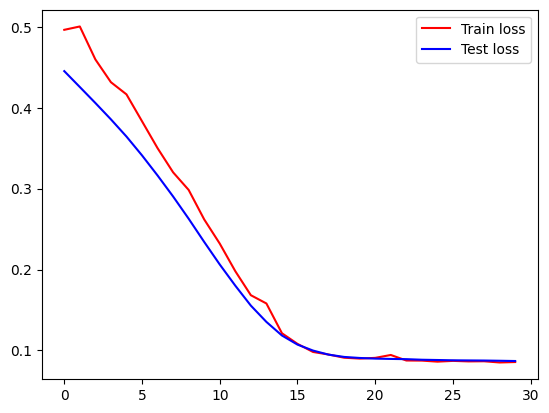

In [34]:
plt.plot(train_losses, color="red", label="Train loss")
plt.plot(test_losses, color="blue", label="Test loss")
plt.legend()

In [35]:
# Evaluate test performance

model.eval_model(test_dataloader)

Test RMSE: 0.24656152725219727
Test MAE: 0.1959589421749115


RMSE: 0.5858575105667114
MAE: 0.5631264448165894
goals_per_90 RMSE: 0.40710175037384033
goals_per_90 MAE: 0.36713969707489014
xG_per_90 RMSE: 0.4072172939777374
xG_per_90 MAE: 0.38525882363319397
assists_per_90 RMSE: 0.2654624581336975
assists_per_90 MAE: 0.2340516448020935
xA_per_90 RMSE: 0.06810757517814636
xA_per_90 MAE: 0.061146080493927
key_passes_per_90 RMSE: 2.230734348297119
key_passes_per_90 MAE: 2.198751211166382
xGChain_per_90 RMSE: 0.45669981837272644
xGChain_per_90 MAE: 0.4349813461303711
xGBuildup_per_90 RMSE: 0.2656794488430023
xGBuildup_per_90 MAE: 0.26055654883384705


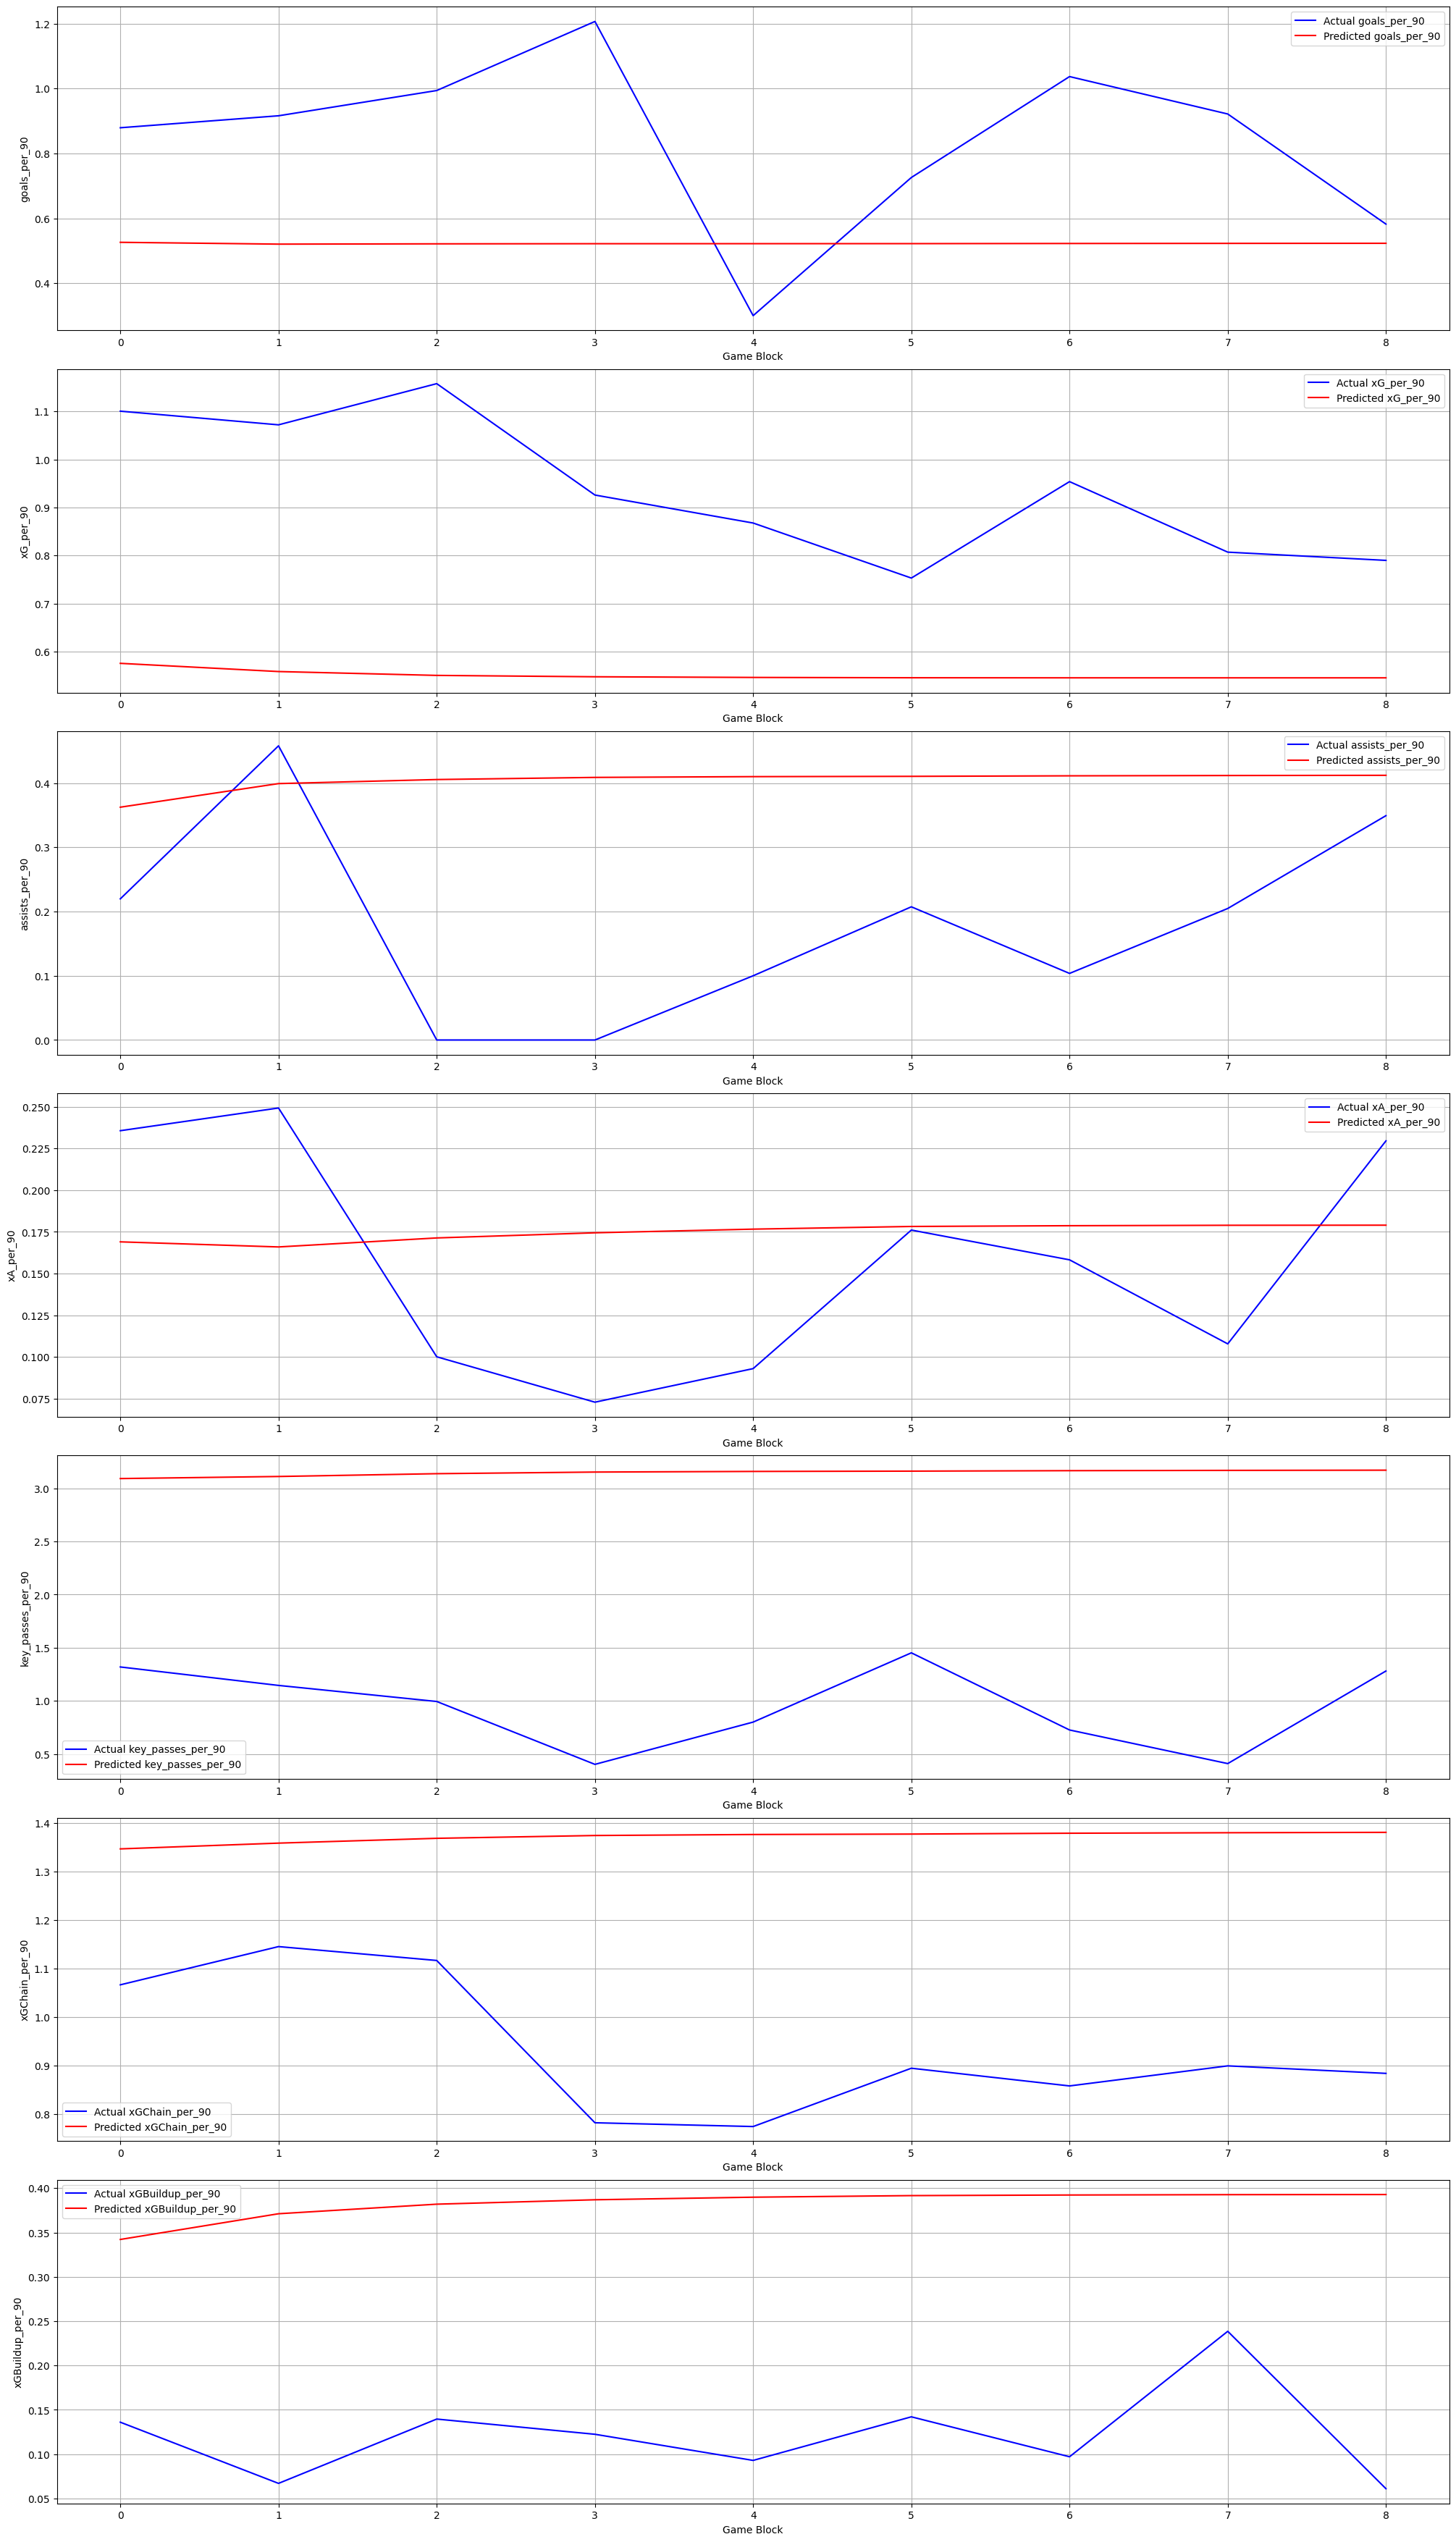

In [36]:
# See how model does on forecasting a specific player--Erling Haaland

haaland_df = f_stats.loc["8260"]

model.eval_model_on_player(haaland_df)